# Stage 3 Experiment: Weight Initialization

This notebook studies how different initialization strategies affect optimization behaviour and final QA performance in the repaired QANet under the shared baseline.


## Research Question

How does weight initialization affect training stability, convergence behaviour, and final evaluation metrics in the repaired QANet?

## Hypothesis

Under the shared baseline, changing `init_name` should mainly affect early optimization and convergence smoothness. Because the repaired QANet uses ReLU activations, the Kaiming family is expected to behave differently from the Xavier family, while normal vs uniform variants may further affect loss scale and training stability.


## Experimental Setup

Controlled setting:
- same training and evaluation data
- same optimizer, scheduler, loss, and model structure
- only `init_name` is changed

Initialization settings compared:
- `kaiming`
- `xavier`
- `kaiming_uniform`
- `xavier_uniform`


## Load Libraries and Experiment Configuration


In [6]:
from TrainTools.train import train
from EvaluateTools.evaluate import evaluate

import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

INIT_SETTINGS = [
    "kaiming",
    "xavier",
    "kaiming_uniform",
    "xavier_normal",
]

RESULTS_DIR = Path("experiments/init_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

train_results = {}
eval_results = {}

---
## Run Training

In [7]:
for init_name in INIT_SETTINGS:
    print(f"===== Training init_name={init_name} =====")
    train_results[init_name] = train(
        train_npz       = "_data/train.npz",
        dev_npz         = "_data/dev.npz",
        word_emb_json   = "_data/word_emb.json",
        char_emb_json   = "_data/char_emb.json",
        train_eval_json = "_data/train_eval.json",
        dev_eval_json   = "_data/dev_eval.json",

        save_dir        = f"experiments/_model_init_{init_name}",
        log_dir         = f"experiments/_log_init_{init_name}",

        num_steps       = 1000,

        optimizer_name  = "sgd",
        scheduler_name  = "lambda",
        loss_name       = "qa_nll",
        init_name       = init_name,
    )

    result_path = RESULTS_DIR / f"train_{init_name}.json"
    with result_path.open("w", encoding="utf-8") as f:
        json.dump(train_results[init_name], f, indent=2)


===== Training init_name=kaiming =====


100%|██████████| 200/200 [02:38<00:00,  1.26it/s]


STEP      200  loss 1821.687456



100%|██████████| 150/150 [00:26<00:00,  5.60it/s]


VALID(train) loss 34.274103  F1 7.092930  EM 0.000000



...

STEP     1000  loss 19.469221



100%|██████████| 150/150 [00:16<00:00,  8.99it/s]


VALID(train) loss 6.534443  F1 6.732330  EM 0.083333



100%|██████████| 150/150 [00:16<00:00,  9.22it/s]


TEST        loss 6.587584  F1 6.055193  EM 0.000000

Learning rate: [0.001]
Training finished.  Best F1: 6.5199  Best EM: 0.4167


---
## Unified Evaluation

In [8]:
for init_name in INIT_SETTINGS:
    print(f"===== Evaluating init_name={init_name} =====")
    eval_results[init_name] = evaluate(
        dev_npz       = "_data/dev.npz",
        word_emb_json = "_data/word_emb.json",
        char_emb_json = "_data/char_emb.json",
        dev_eval_json = "_data/dev_eval.json",

        save_dir      = f"experiments/_model_init_{init_name}",
        log_dir       = f"experiments/_log_init_{init_name}",
    )

    result_path = RESULTS_DIR / f"eval_{init_name}.json"
    with result_path.open("w", encoding="utf-8") as f:
        json.dump(eval_results[init_name], f, indent=2)

    print(
        f"Init={init_name} | Eval F1: {eval_results[init_name]['f1']:.4f} | "
        f"Eval EM: {eval_results[init_name]['exact_match']:.4f} | "
        f"Eval Loss: {eval_results[init_name]['loss']:.6f}"
    )


===== Evaluating init_name=kaiming =====


100%|██████████| 1309/1309 [02:21<00:00,  9.26it/s]


TEST  loss 17.387996  F1 7.597898  EM 0.172002
Init=kaiming | Eval F1: 7.5979 | Eval EM: 0.1720 | Eval Loss: 17.387996
===== Evaluating init_name=xavier =====


100%|██████████| 1309/1309 [02:35<00:00,  8.43it/s]


TEST  loss 6.445737  F1 8.567583  EM 0.000000
Init=xavier | Eval F1: 8.5676 | Eval EM: 0.0000 | Eval Loss: 6.445737
===== Evaluating init_name=kaiming_uniform =====


100%|██████████| 1309/1309 [02:26<00:00,  8.95it/s]


TEST  loss 23.760960  F1 7.952278  EM 0.047778
Init=kaiming_uniform | Eval F1: 7.9523 | Eval EM: 0.0478 | Eval Loss: 23.760960
===== Evaluating init_name=xavier_normal =====


100%|██████████| 1309/1309 [02:29<00:00,  8.77it/s]


TEST  loss 6.832353  F1 7.364475  EM 0.000000
Init=xavier_normal | Eval F1: 7.3645 | Eval EM: 0.0000 | Eval Loss: 6.832353


## Build the Summary Table



In [9]:
train_results = {}
eval_results = {}
available_settings = []

for init_name in INIT_SETTINGS:
    train_path = RESULTS_DIR / f"train_{init_name}.json"
    eval_path = RESULTS_DIR / f"eval_{init_name}.json"
    if train_path.exists() and eval_path.exists():
        with train_path.open("r", encoding="utf-8") as f:
            train_results[init_name] = json.load(f)
        with eval_path.open("r", encoding="utf-8") as f:
            eval_results[init_name] = json.load(f)
        available_settings.append(init_name)

print("Available settings:", available_settings)

summary_rows = []
for init_name in available_settings:
    history = train_results[init_name]["history"]
    last_entry = history[-1]
    best_entry = max(history, key=lambda row: row["dev_f1"])
    summary_rows.append({
        "init_name": init_name,
        "last_step": last_entry["step"],
        "final_train_loss": last_entry["train_loss"],
        "final_dev_loss": last_entry["dev_loss"],
        "best_dev_f1": train_results[init_name]["best_f1"],
        "best_dev_em": train_results[init_name]["best_em"],
        "best_dev_step": best_entry["step"],
        "eval_f1": eval_results[init_name]["f1"],
        "eval_em": eval_results[init_name]["exact_match"],
        "eval_loss": eval_results[init_name]["loss"],
    })

summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    print("No completed settings are available for summary.")
else:
    summary_df = summary_df.sort_values("init_name").reset_index(drop=True)
    print(summary_df.to_string(index=False))
    summary_df


Available settings: ['kaiming', 'xavier', 'kaiming_uniform', 'xavier_normal']
      init_name  last_step  final_train_loss  final_dev_loss  best_dev_f1  best_dev_em  best_dev_step  eval_f1  eval_em  eval_loss
        kaiming       1000        209.813018       16.832417     6.216593     0.166667            400 7.597898 0.172002  17.387996
kaiming_uniform       1000        412.054348       22.713580     7.103445     0.083333            400 7.952278 0.047778  23.760960
         xavier       1000         19.288335        6.284677     6.465764     0.000000           1000 8.567583 0.000000   6.445737
  xavier_normal       1000         19.469221        6.587584     6.519894     0.416667            400 7.364475 0.000000   6.832353


## Plot Convergence Curves



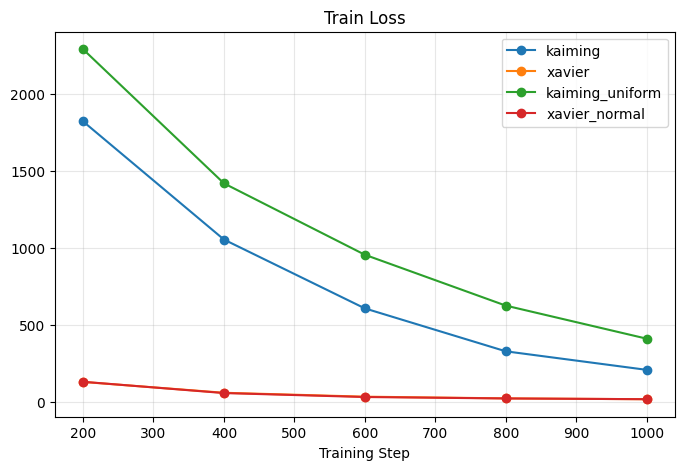

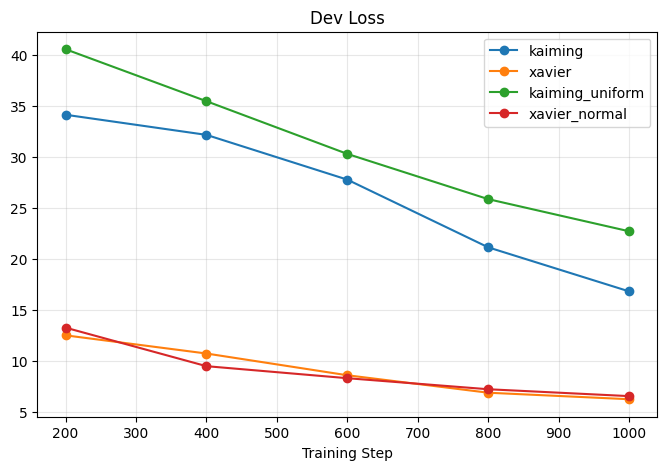

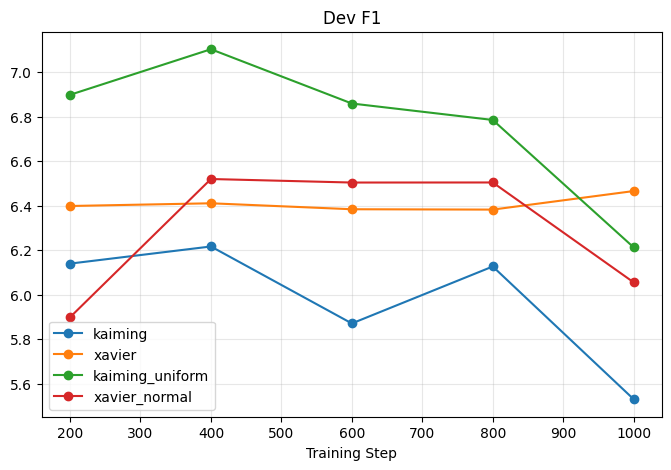

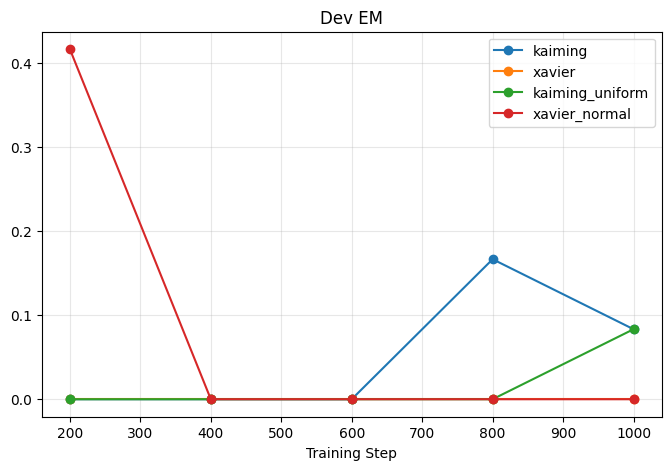

In [10]:
train_results_disk = {}
available_settings_disk = []

for init_name in INIT_SETTINGS:
    train_path = RESULTS_DIR / f"train_{init_name}.json"
    if train_path.exists():
        with train_path.open("r", encoding="utf-8") as f:
            train_results_disk[init_name] = json.load(f)
        available_settings_disk.append(init_name)

if not available_settings_disk:
    raise ValueError("No saved training results available. Run training first.")

metrics_to_plot = [
    ("train_loss", "Train Loss"),
    ("dev_loss", "Dev Loss"),
    ("dev_f1", "Dev F1"),
    ("dev_em", "Dev EM"),
]

for metric_key, metric_title in metrics_to_plot:
    fig, ax = plt.subplots(figsize=(8, 5))
    for init_name in available_settings_disk:
        history_df = pd.DataFrame(train_results_disk[init_name]["history"])
        ax.plot(
            history_df["step"].tolist(),
            history_df[metric_key].tolist(),
            marker="o",
            label=init_name,
        )
    ax.set_title(metric_title)
    ax.set_xlabel("Training Step")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


## Plot Final Metric Comparisons



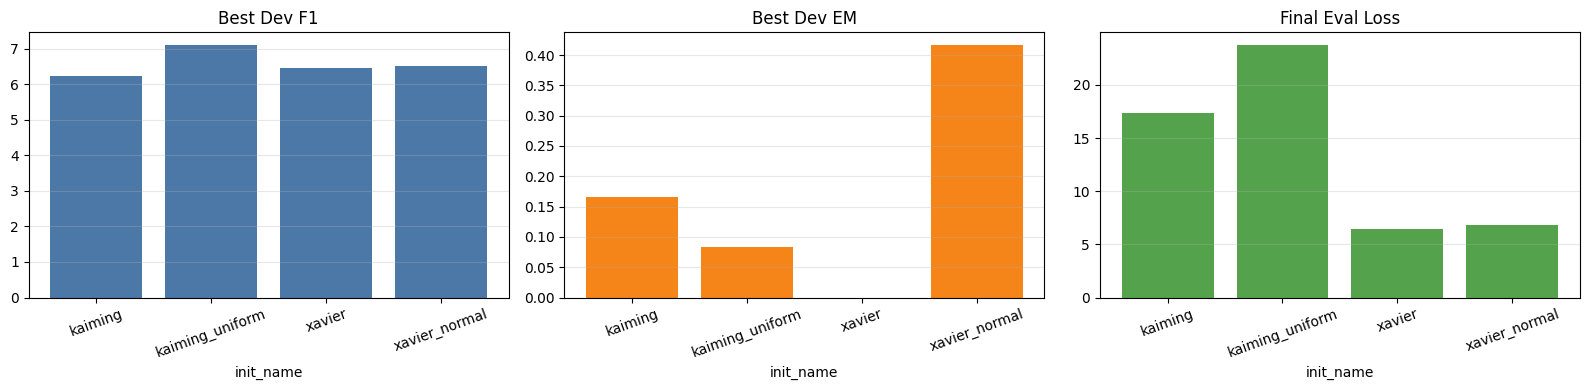

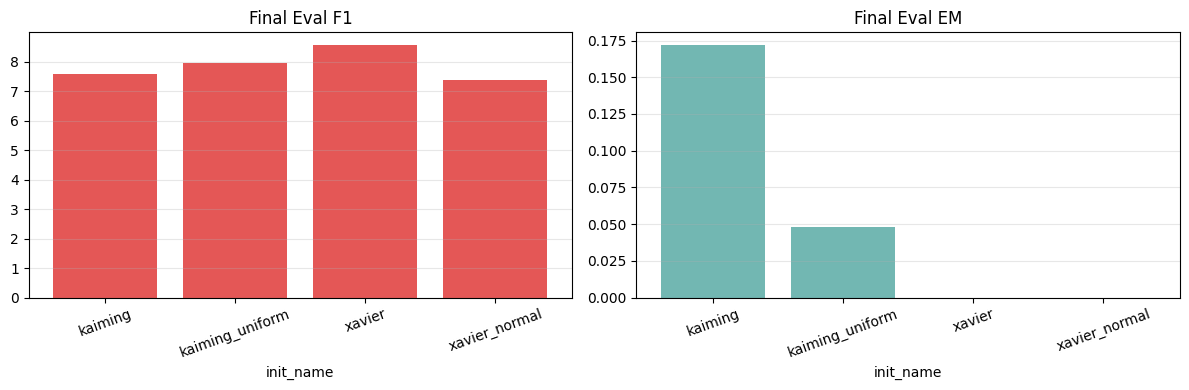

In [11]:
train_results = {}
eval_results = {}
available_settings = []

for init_name in INIT_SETTINGS:
    train_path = RESULTS_DIR / f"train_{init_name}.json"
    eval_path = RESULTS_DIR / f"eval_{init_name}.json"
    if train_path.exists() and eval_path.exists():
        with train_path.open("r", encoding="utf-8") as f:
            train_results[init_name] = json.load(f)
        with eval_path.open("r", encoding="utf-8") as f:
            eval_results[init_name] = json.load(f)
        available_settings.append(init_name)

plot_rows = []
for init_name in available_settings:
    history = train_results[init_name]["history"]
    best_entry = max(history, key=lambda row: row["dev_f1"])
    plot_rows.append({
        "init_name": init_name,
        "best_dev_f1": train_results[init_name]["best_f1"],
        "best_dev_em": train_results[init_name]["best_em"],
        "best_dev_step": best_entry["step"],
        "eval_f1": eval_results[init_name]["f1"],
        "eval_em": eval_results[init_name]["exact_match"],
        "eval_loss": eval_results[init_name]["loss"],
    })

plot_df = pd.DataFrame(plot_rows)
if plot_df.empty:
    raise ValueError("No saved summary data is available. Run training/evaluation first.")

plot_df = plot_df.sort_values("init_name").reset_index(drop=True)
x_labels = plot_df["init_name"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(x_labels, plot_df["best_dev_f1"], color="#4C78A8")
axes[0].set_title("Best Dev F1")
axes[0].set_xlabel("init_name")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(x_labels, plot_df["best_dev_em"], color="#F58518")
axes[1].set_title("Best Dev EM")
axes[1].set_xlabel("init_name")
axes[1].tick_params(axis="x", rotation=20)
axes[2].bar(x_labels, plot_df["eval_loss"], color="#54A24B")
axes[2].set_title("Final Eval Loss")
axes[2].set_xlabel("init_name")
axes[2].tick_params(axis="x", rotation=20)
for ax in axes:
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(x_labels, plot_df["eval_f1"], color="#E45756")
axes[0].set_title("Final Eval F1")
axes[0].set_xlabel("init_name")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(x_labels, plot_df["eval_em"], color="#72B7B2")
axes[1].set_title("Final Eval EM")
axes[1].set_xlabel("init_name")
axes[1].tick_params(axis="x", rotation=20)
for ax in axes:
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
